In [1]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the pack

In [2]:
import os
from pathlib import Path
from PIL import Image, UnidentifiedImageError
Image.MAX_IMAGE_PIXELS = None  
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as T
from torchvision.models import swin_v2_b, convnext_base
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import clip

# 1. CONFIG & SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

INPUT_SIZE = 336
BATCH_SIZE = 16 
NUM_WORKERS = 2
DATASET_PATH = Path('/kaggle/input/chayrung-multiclass/the_wildfire_dataset/the_wildfire_dataset')

# 2. DATASET & DATALOADER
test_transform = T.Compose([
    T.Resize((INPUT_SIZE, INPUT_SIZE)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Using device: cuda


In [3]:
class WildfireDataset(Dataset):
    SUBCLASS_MAP = {
        'Both_smoke_and_fire': 0,
        'Smoke_from_fires': 1,
        'Fire_confounding_elements': 2,
        'Forested_areas_without_confounding_elements': 3,
        'Smoke_confounding_elements': 4
    }

    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        self._load_samples()
        print(f"Loaded {len(self.samples)} test images.")

    def _load_samples(self):
        for class_name in ['fire', 'nofire']:
            class_dir = self.root_dir / class_name
            if not class_dir.exists(): continue
            
            for subclass_dir in class_dir.iterdir():
                if not subclass_dir.is_dir() or subclass_dir.name not in self.SUBCLASS_MAP:
                    continue
                multiclass_label = self.SUBCLASS_MAP[subclass_dir.name]
                
                for img_path in subclass_dir.glob('*'):
                    if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                        self.samples.append({
                            'path': img_path,
                            'multiclass_label': multiclass_label
                        })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        try:
            image = Image.open(sample['path']).convert('RGB')
            if self.transform: image = self.transform(image)
            return {
                'image': image,
                'multiclass_label': torch.tensor(sample['multiclass_label'], dtype=torch.long)
            }
        except Exception:
            return self.__getitem__((idx + 1) % len(self))

# Init DataLoader
print("Initializing Test Loader...")
test_dataset = WildfireDataset(root_dir=DATASET_PATH / 'test', transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Initializing Test Loader...
Loaded 410 test images.


In [ ]:
# 3. MODEL DEFINITION
CLIP_MODEL_NAME = "ViT-L/14@336px"
CLIP_IN_FEATURES = 768

class MultiClassWildfireModel(nn.Module):
    def __init__(self, num_multi=5, backbone="swin", dropout_rate=0.2):
        super().__init__()
        self.backbone_name = backbone.lower()
        
        in_features = 0 # Placeholder

        # Swin Backbone
        if "swin" in self.backbone_name:
            from torchvision.models import swin_v2_b
            self.base = swin_v2_b(weights=None)
            in_features = self.base.head.in_features
            self.base.head = nn.Identity()
            
        elif "clip" in self.backbone_name:
            import clip 
            clip_model, _ = clip.load(CLIP_MODEL_NAME, device="cpu", jit=False)
            self.base = clip_model.visual.float() 
            in_features = CLIP_IN_FEATURES
            
        else:
            raise ValueError("Backbone not supported (Chỉ hỗ trợ Swin và CLIP)")

        # Shared FC Layers 
        self.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate)
        )
        self.multi = nn.Linear(256, num_multi)

    def forward(self, x):
        x = self.base(x)
        x = self.fc(x)
        return self.multi(x)


In [5]:
# 4. UTILS: LOAD WEIGHTS & ENSEMBLE
def load_trained_weights(model, weight_path):
    print(f"Loading weights: {weight_path}")
    if not os.path.exists(weight_path):
        print(f"File not found: {weight_path}")
        return
        
    checkpoint = torch.load(weight_path, map_location='cpu')
    state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

    # Clean prefix
    new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    
    try:
        model.load_state_dict(new_state_dict, strict=True)
        print("-> Success (Strict Load)")
    except RuntimeError as e:
        print(f"-> Warning: Strict load failed. Trying non-strict. Error: {e}")
        model.load_state_dict(new_state_dict, strict=False)
        
def run_ensemble(loader, model1, model2, w1=0.6, w2=0.4):
    model1.eval()
    model2.eval()
    all_targets, all_preds = [], []
    
    print(f"\nRunning Ensemble (Swin={w1}, Clip={w2})...")
    with torch.no_grad():
        for batch in tqdm(loader):
            images = batch['image'].to(device)
            targets = batch['multiclass_label'].to(device)
            
            # Prediction
            probs1 = F.softmax(model1(images), dim=1)
            probs2 = F.softmax(model2(images), dim=1)
            
            # Weighted Vote
            avg_probs = (probs1 * w1) + (probs2 * w2)
            preds = torch.argmax(avg_probs, dim=1)
            
            all_targets.extend(targets.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            
    return np.array(all_targets), np.array(all_preds)

In [6]:
def grid_search_ensemble(
    loader,
    model1,
    model2,
    step=0.05
):
    best_acc = 0.0
    best_w = (0.5, 0.5)
    results = []

    print("\nStarting Grid Search for Ensemble Weights...")
    
    weights = np.linspace(0.0, 1.0, int(1/step) + 1)

    for w1 in weights:
        w1 = round(float(w1), 2)
        w2 = round(1.0 - w1, 2)
        if w2 < 0: 
            continue

        y_true, y_pred = run_ensemble(
            loader,
            model1,
            model2,
            w1=w1,
            w2=w2
        )

        acc = accuracy_score(y_true, y_pred)
        results.append((w1, w2, acc))

        print(f"w1={w1:.2f}, w2={w2:.2f} -> Acc={acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_w = (w1, w2)

    print("\n" + "="*40)
    print(f"BEST RESULT:")
    print(f"w1 (Swin) = {best_w[0]:.2f}")
    print(f"w2 (CLIP) = {best_w[1]:.2f}")
    print(f"Accuracy  = {best_acc:.4f}")
    print("="*40)

    return best_w, best_acc, results

In [7]:
# 5. EXECUTION
# Paths
swin_path = "/kaggle/input/swin-8951-lrs/transformers/default/1/swin_batch_16_acc_8951_test.pth"
clip_path = "/kaggle/input/clip-ultimate/transformers/default/1/best_multiclass_model_state_ultimate.pth"

# Init Models
print("\nInitializing Models...")
swin_model = MultiClassWildfireModel(backbone="swin").to(device)
clip_model = MultiClassWildfireModel(backbone="clip").to(device)

# Load Weights
load_trained_weights(swin_model, swin_path)
load_trained_weights(clip_model, clip_path)


Initializing Models...


100%|████████████████████████████████████████| 891M/891M [00:05<00:00, 167MiB/s]


Loading weights: /kaggle/input/swin-8951-lrs/transformers/default/1/swin_batch_16_acc_8951_test.pth
-> Success (Strict Load)
Loading weights: /kaggle/input/clip-ultimate/transformers/default/1/best_multiclass_model_state_ultimate.pth
-> Success (Strict Load)


In [8]:
# Run Ensemble
best_w, best_acc, grid_results = grid_search_ensemble(
    test_loader,
    swin_model,
    clip_model,
    step=0.05 
)


Starting Grid Search for Ensemble Weights...

Running Ensemble (Swin=0.0, Clip=1.0)...


100%|██████████| 26/26 [01:17<00:00,  2.98s/it]


w1=0.00, w2=1.00 -> Acc=0.9098

Running Ensemble (Swin=0.05, Clip=0.95)...


100%|██████████| 26/26 [01:12<00:00,  2.79s/it]


w1=0.05, w2=0.95 -> Acc=0.9098

Running Ensemble (Swin=0.1, Clip=0.9)...


...

w1=0.90, w2=0.10 -> Acc=0.8976

Running Ensemble (Swin=0.95, Clip=0.05)...


100%|██████████| 26/26 [01:17<00:00,  2.98s/it]


w1=0.95, w2=0.05 -> Acc=0.8878

Running Ensemble (Swin=1.0, Clip=0.0)...


100%|██████████| 26/26 [01:16<00:00,  2.96s/it]

w1=1.00, w2=0.00 -> Acc=0.8805

BEST RESULT:
w1 (Swin) = 0.50
w2 (CLIP) = 0.50
Accuracy  = 0.9195



Running Ensemble (Swin=0.5, Clip=0.5)...


100%|██████████| 26/26 [01:14<00:00,  2.88s/it]



FINAL ENSEMBLE ACCURACY: 0.9195

                                             precision    recall  f1-score   support

                        Both_smoke_and_fire     0.9649    0.9322    0.9483        59
                           Smoke_from_fires     0.9500    0.9500    0.9500       100
                  Fire_confounding_elements     0.7544    0.8269    0.7890        52
Forested_areas_without_confounding_elements     0.9672    0.9219    0.9440       128
                 Smoke_confounding_elements     0.8919    0.9296    0.9103        71

                                   accuracy                         0.9195       410
                                  macro avg     0.9057    0.9121    0.9083       410
                               weighted avg     0.9226    0.9195    0.9206       410



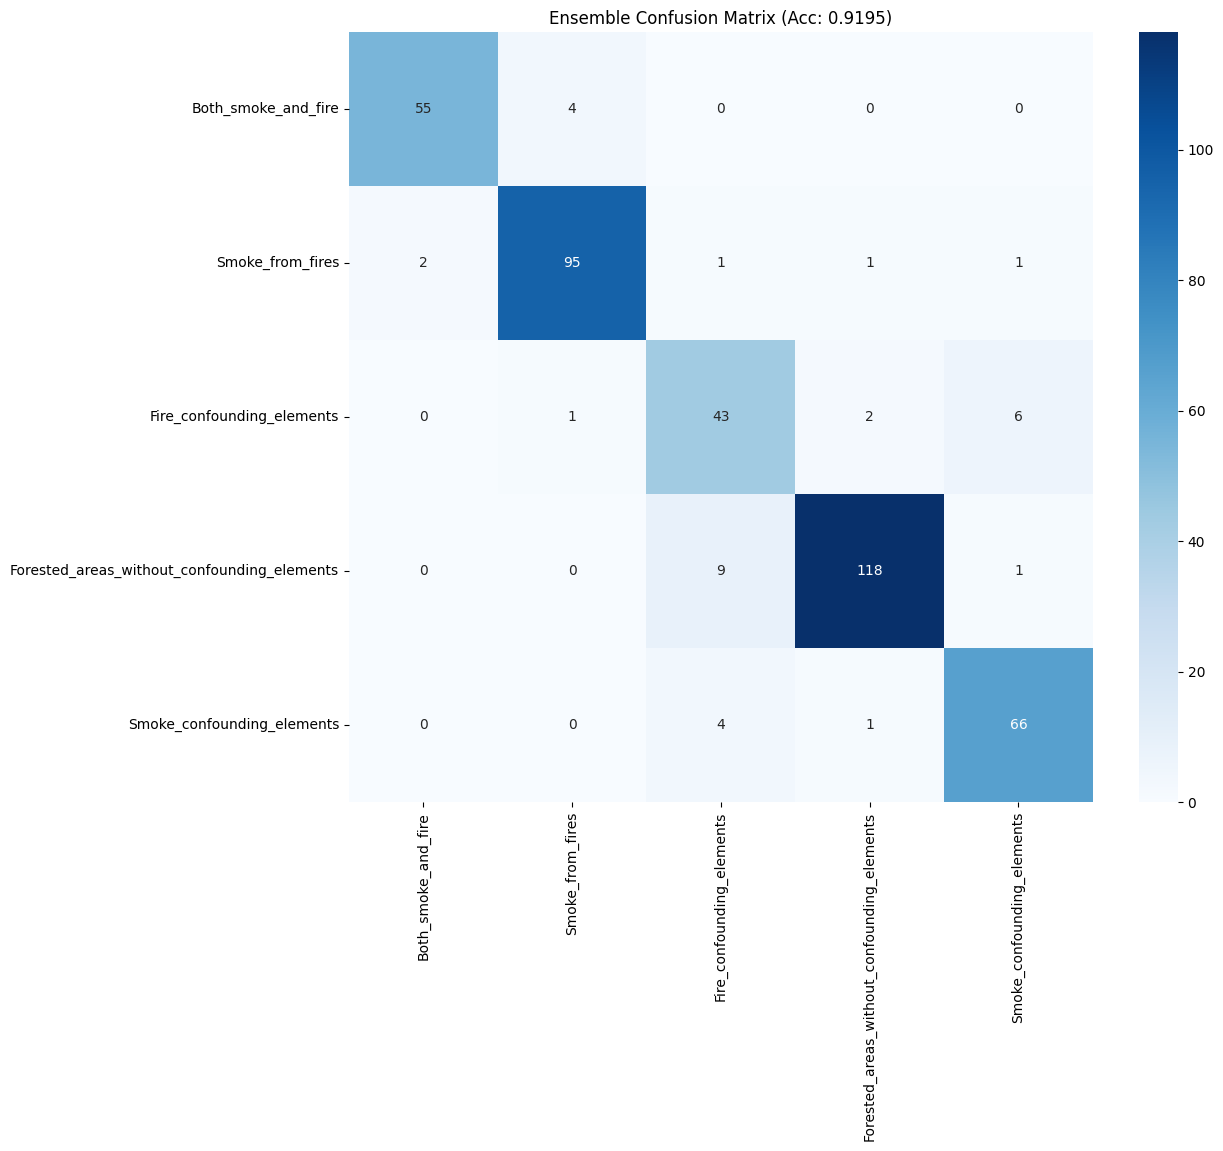

In [9]:
w1_opt, w2_opt = best_w

y_true, y_pred = run_ensemble(
    test_loader,
    swin_model,
    clip_model,
    w1=w1_opt,
    w2=w2_opt
)

# Report
acc = accuracy_score(y_true, y_pred)
print(f"\n{'='*30}\nFINAL ENSEMBLE ACCURACY: {acc:.4f}\n{'='*30}\n")

target_names = [k for k, v in sorted(WildfireDataset.SUBCLASS_MAP.items(), key=lambda item: item[1])]
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Ensemble Confusion Matrix (Acc: {acc:.4f})')
plt.show()

In [10]:
# Unpack grid search results
w1_values = [r[0] for r in grid_results]
acc_values = [r[2] for r in grid_results]

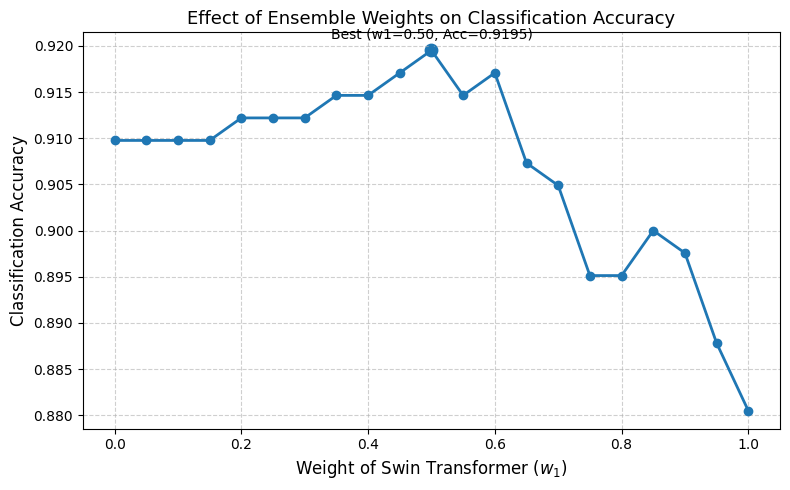

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    w1_values,
    acc_values,
    marker='o',
    linewidth=2
)

plt.xlabel("Weight of Swin Transformer ($w_1$)", fontsize=12)
plt.ylabel("Classification Accuracy", fontsize=12)
plt.title("Effect of Ensemble Weights on Classification Accuracy", fontsize=13)

# Highlight best point
best_idx = np.argmax(acc_values)
plt.scatter(
    w1_values[best_idx],
    acc_values[best_idx],
    s=80
)
plt.annotate(
    f"Best (w1={w1_values[best_idx]:.2f}, Acc={acc_values[best_idx]:.4f})",
    (w1_values[best_idx], acc_values[best_idx]),
    textcoords="offset points",
    xytext=(0, 8),
    ha='center',
    fontsize=10
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [12]:
plt.savefig(
    "ensemble_weight_vs_accuracy.pdf",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [13]:
plt.savefig(
    "ensemble_weight_vs_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>